# Exploratory Data Analysis (EDA) - Credit Scoring Project
## Overview
This notebook explores the Home Credit dataset to identify patterns, data quality issues, and opportunities for feature engineering. We analyze several data sources:
1. `application_train.csv` / `application_test.csv` - Main application data
2. `bureau.csv` / `bureau_balance.csv` - Data from the Credit Bureau
3. `previous_application.csv` - Previous applications at Home Credit
4. `POS_CASH_balance.csv` - Monthly data on POS/Cash loans
5. `installments_payments.csv` - Repayment history
6. `credit_card_balance.csv` - Monthly data on credit card balance

## 1. Target Variable Analysis
The target variable `TARGET` indicates if a client had payment difficulties (1) or not (0).

Target Distribution: TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


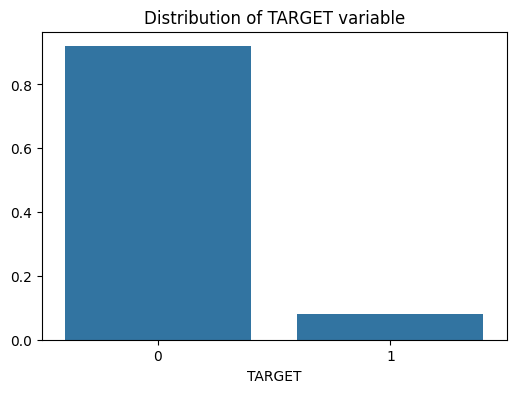

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_app = pd.read_csv('../../data/application_train.csv')
target_counts = df_app['TARGET'].value_counts(normalize=True)
print("Target Distribution:", target_counts)
plt.figure(figsize=(6,4))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title('Distribution of TARGET variable')
plt.show()

**Findings:**
- The target is highly imbalanced.
- Approximately 91.9% of clients repaid their loans (0).
- Approximately 8.1% of clients had payment difficulties (1).

## 2. Application Data Analysis

### Numeric Features and Anomalies

       AMT_INCOME_TOTAL    AMT_CREDIT    AMT_ANNUITY     DAYS_BIRTH  \
count      3.075110e+05  3.075110e+05  307499.000000  307511.000000   
mean       1.687979e+05  5.990260e+05   27108.573909  -16036.995067   
std        2.371231e+05  4.024908e+05   14493.737315    4363.988632   
min        2.565000e+04  4.500000e+04    1615.500000  -25229.000000   
25%        1.125000e+05  2.700000e+05   16524.000000  -19682.000000   
50%        1.471500e+05  5.135310e+05   24903.000000  -15750.000000   
75%        2.025000e+05  8.086500e+05   34596.000000  -12413.000000   
max        1.170000e+08  4.050000e+06  258025.500000   -7489.000000   

       DAYS_EMPLOYED  
count  307511.000000  
mean    63815.045904  
std    141275.766519  
min    -17912.000000  
25%     -2760.000000  
50%     -1213.000000  
75%      -289.000000  
max    365243.000000  
Number of anomalies in DAYS_EMPLOYED (365243): 55374


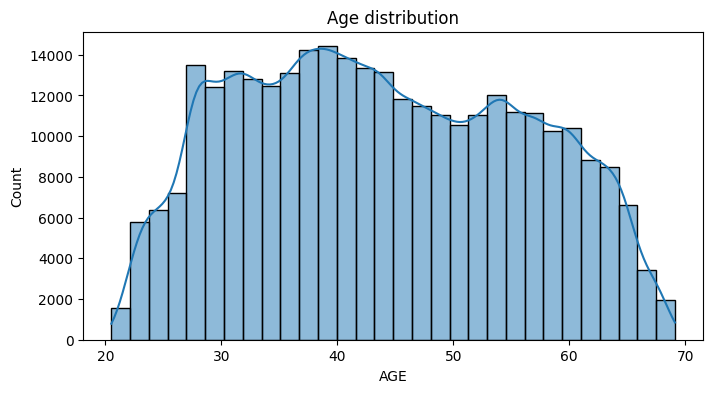

In [5]:
cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
print(df_app[cols].describe())

# Investigating DAYS_EMPLOYED anomaly
print("Number of anomalies in DAYS_EMPLOYED (365243):", (df_app['DAYS_EMPLOYED'] == 365243).sum())

# Age analysis
df_app['AGE'] = df_app['DAYS_BIRTH'] / -365
plt.figure(figsize=(8,4))
sns.histplot(df_app['AGE'], bins=30, kde=True)
plt.title('Age distribution')
plt.show()

### External Sources
The features `EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3` are normalized scores from external data sources. They are typically the most predictive features.

Correlations with TARGET: EXT_SOURCE_3   -0.178919
EXT_SOURCE_2   -0.160472
EXT_SOURCE_1   -0.155317
TARGET          1.000000
Name: TARGET, dtype: float64


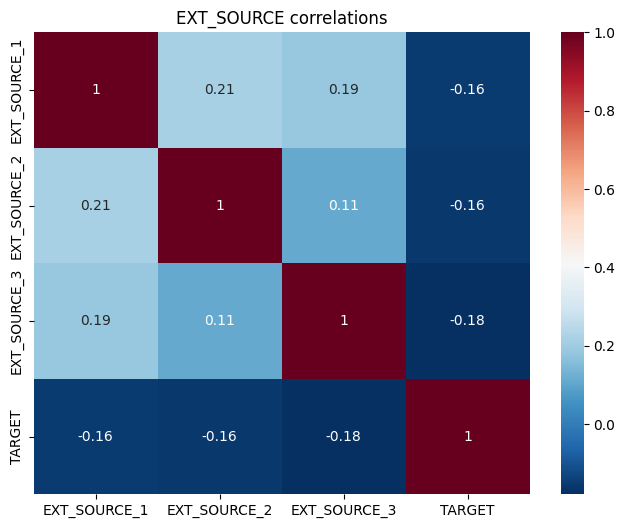

In [3]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET']
corr = df_app[ext_cols].corr()
print("Correlations with TARGET:", corr['TARGET'].sort_values())

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='RdBu_r')
plt.title('EXT_SOURCE correlations')
plt.show()

### Categorical Features

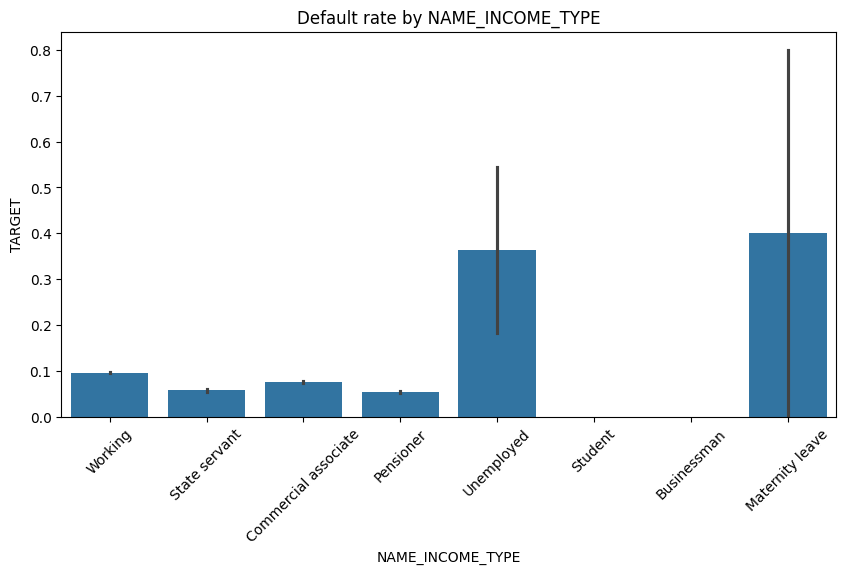

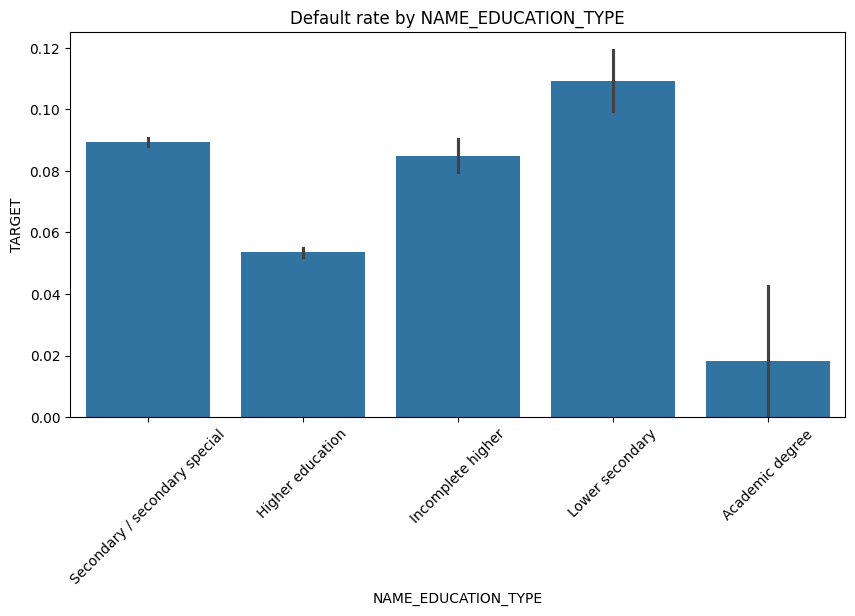

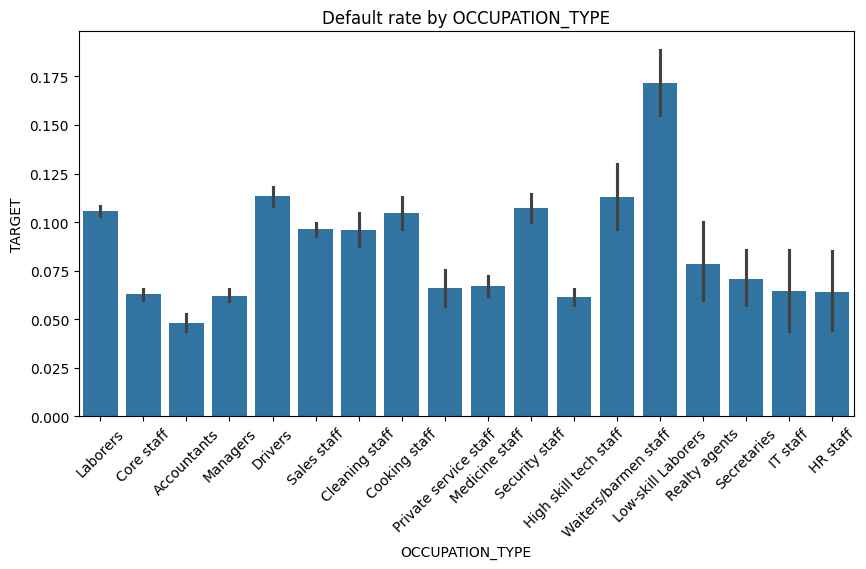

In [4]:
def plot_categorical(df, column):
    plt.figure(figsize=(10,5))
    sns.barplot(x=column, y='TARGET', data=df)
    plt.xticks(rotation=45)
    plt.title(f'Default rate by {column}')
    plt.show()

plot_categorical(df_app, 'NAME_INCOME_TYPE')
plot_categorical(df_app, 'NAME_EDUCATION_TYPE')
plot_categorical(df_app, 'OCCUPATION_TYPE')

## 3. Bureau Data Analysis

Credits per applicant count: count    305811.000000
mean          5.612709
std           4.430354
min           1.000000
25%           2.000000
50%           4.000000
75%           8.000000
max         116.000000
Name: SK_ID_BUREAU, dtype: float64


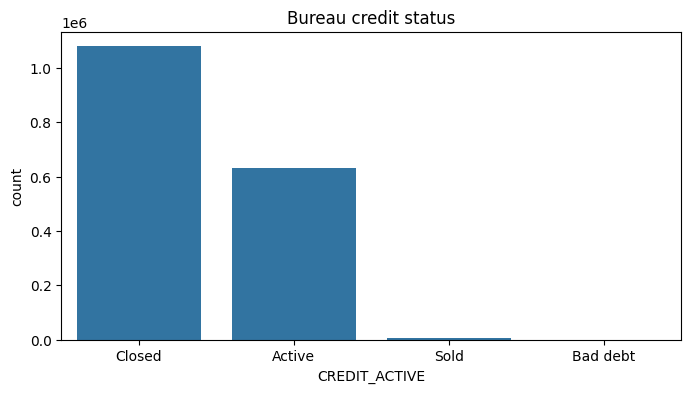

In [5]:
df_bureau = pd.read_csv('../../data/bureau.csv')
print("Credits per applicant count:", df_bureau.groupby('SK_ID_CURR')['SK_ID_BUREAU'].count().describe())

plt.figure(figsize=(8,4))
sns.countplot(x='CREDIT_ACTIVE', data=df_bureau)
plt.title('Bureau credit status')
plt.show()

## 4. Previous Applications Analysis

Contract Status Distribution: NAME_CONTRACT_STATUS
Approved        0.620747
Canceled        0.189388
Refused         0.174036
Unused offer    0.015828
Name: proportion, dtype: float64


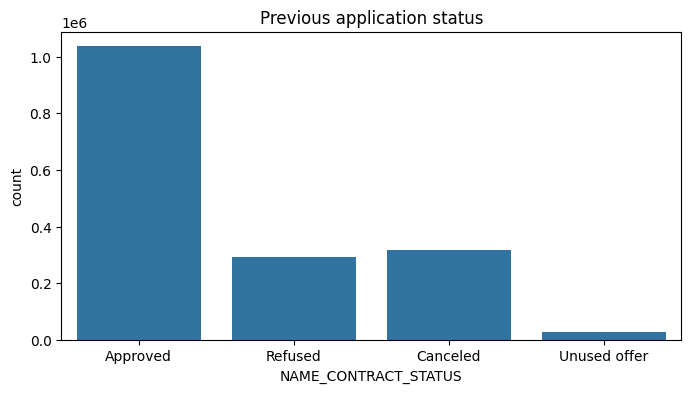

In [3]:
df_prev = pd.read_csv('../../data/previous_application.csv')
print("Contract Status Distribution:", df_prev['NAME_CONTRACT_STATUS'].value_counts(normalize=True))

plt.figure(figsize=(8,4))
sns.countplot(x='NAME_CONTRACT_STATUS', data=df_prev)
plt.title('Previous application status')
plt.show()

## 5. Summary and Next Steps

**Summary of findings:**
1. **Imbalance:** The dataset is imbalanced (8.1% default rate). We should use AUC-ROC instead of accuracy.
2. **Anomalies:** `DAYS_EMPLOYED` contains 365243 as a code for "unemployed" or similar. This needs treatment.
3. **Predictors:** `EXT_SOURCE_*` are strong negative predictors of default.
4. **Categorical Signals:** Income type (Maternity leave, Unemployed) and certain occupations (Low-skill Laborers) show significantly higher risk.
5. **Bureau/Prev Data:** Many applicants have extensive histories with other bureaus and Home Credit, which can be aggregated into summary features.

**Next Steps:**
- Preprocessing: Handle `DAYS_EMPLOYED` anomaly, impute missing values (especially for `EXT_SOURCE`).
- Feature Engineering: Aggregate data from `bureau`, `previous_application`, and `installments_payments` tables.